# Galaxy Classifier - EDA
Galaxy10 DECals dataset, 17,736 images across 10 morphological classes.
We'll remap to 3 broader classes for the classifier.


In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os

os.makedirs("../results", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## 1. Load the data

In [2]:
with h5py.File("../data/Galaxy10_DECals.h5", "r") as f:
    X = f["images"][:]    # (17736, 256, 256, 3)  uint8
    y = f["ans"][:]       # (17736,)

print(f"X: {X.shape}  dtype={X.dtype}")
print(f"y: {y.shape}  unique={np.unique(y)}")

X: (17736, 256, 256, 3)  dtype=uint8
y: (17736,)  unique=[0 1 2 3 4 5 6 7 8 9]


## 2. Class names & 3-class remapping

In [3]:
# original 10 class names
class10_names = [
    "Disturbed",           # 0
    "Merging",             # 1
    "Round Smooth",        # 2
    "In-between Smooth",   # 3
    "Cigar Smooth",        # 4
    "Barred Spiral",       # 5
    "Unbarred Tight Spiral", # 6
    "Unbarred Loose Spiral", # 7
    "Edge-on (no bulge)",  # 8
    "Edge-on (with bulge)" # 9
]

# 3 broad morphological groups
remap = {2:0, 3:0, 4:0,        # smooth / elliptical
         5:1, 6:1, 7:1,        # spiral
         0:2, 1:2, 8:2, 9:2}   # edge-on / disturbed

class3_names  = ["Smooth / Elliptical", "Spiral", "Edge-on / Disturbed"]
class3_colors = ["#5DCAA5", "#AFA9EC", "#F0997B"]

y3 = np.array([remap[label] for label in y])

for i, name in enumerate(class3_names):
    print(f"  {i} {name}: {(y3 == i).sum():,}")

  0 Smooth / Elliptical: 5,006
  1 Spiral: 6,500
  2 Edge-on / Disturbed: 6,230


## 3. Class distribution

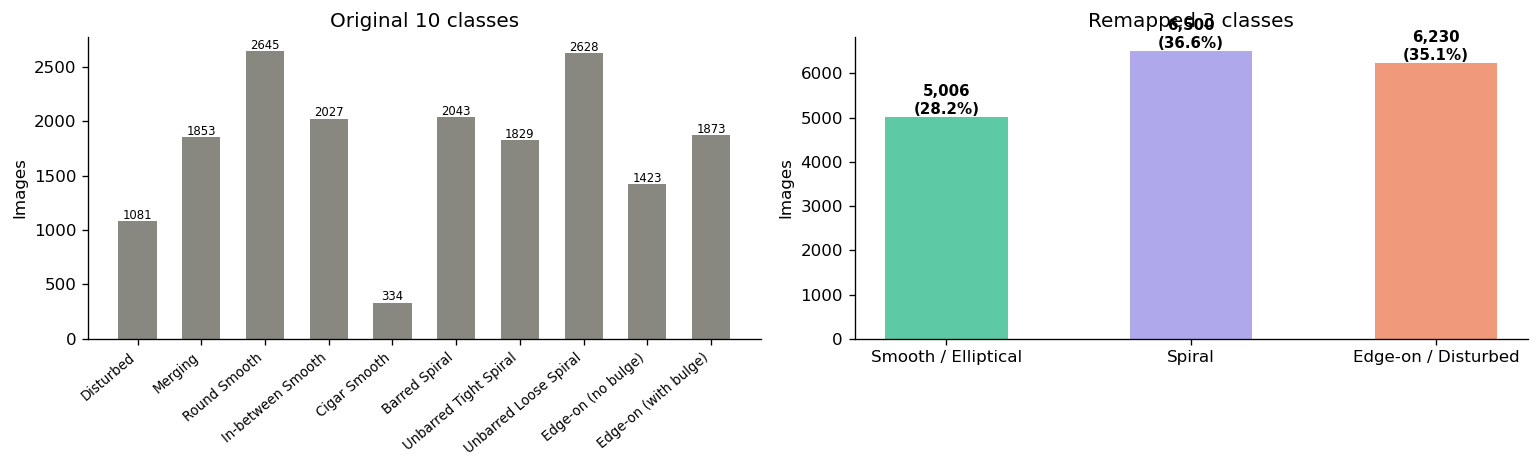

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# left: original 10 classes
counts10 = [(y == i).sum() for i in range(10)]
bars = ax1.bar(range(10), counts10, color="#888780", edgecolor="none", width=0.6)
ax1.set_xticks(range(10))
ax1.set_xticklabels(class10_names, rotation=40, ha="right", fontsize=8)
ax1.set_title("Original 10 classes")
ax1.set_ylabel("Images")
for bar, n in zip(bars, counts10):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(n), ha="center", fontsize=7)

# right: remapped 3 classes
counts3 = [(y3 == i).sum() for i in range(3)]
bars2 = ax2.bar(class3_names, counts3,
                color=class3_colors, edgecolor="none", width=0.5)
ax2.set_title("Remapped 3 classes")
ax2.set_ylabel("Images")
for bar, n, pct in zip(bars2, counts3, [n/len(y3)*100 for n in counts3]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             f"{n:,}\n({pct:.1f}%)", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/class_distribution.png", bbox_inches="tight")
plt.show()

## 4. Sample image grid
5 random examples from each of the 3 broad classes

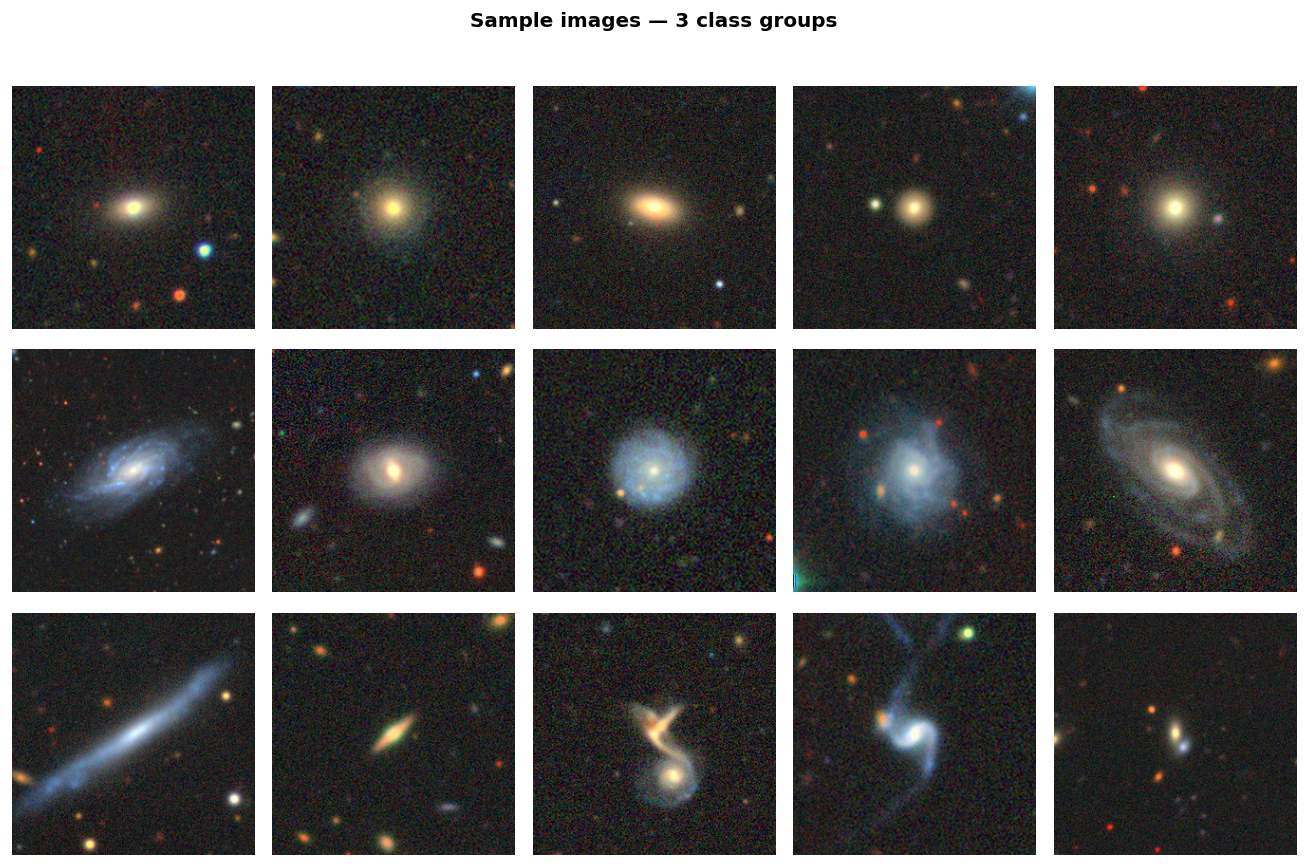

In [5]:
N = 5
fig, axes = plt.subplots(3, N, figsize=(N*2.2, 3*2.4))
fig.suptitle("Sample images — 3 class groups", fontweight="bold", y=1.01)

rng = np.random.default_rng(42)

for row, (cls, name, color) in enumerate(zip(range(3), class3_names, class3_colors)):
    idxs = np.where(y3 == cls)[0]
    picks = rng.choice(idxs, size=N, replace=False)

    for col, idx in enumerate(picks):
        ax = axes[row, col]
        ax.imshow(X[idx])
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
        if col == 0:
            ax.set_ylabel(name, color=color, fontweight="bold", fontsize=9)
            ax.yaxis.set_label_position("left")

plt.tight_layout()
plt.savefig("../results/sample_grid.png", bbox_inches="tight", dpi=150)
plt.show()

## 5. Mean image per class
Average all images in each class. This shows the "typical" galaxy for each morphology.
Spiral arms should appear faintly in the middle row if the averaging doesn't wash them out.


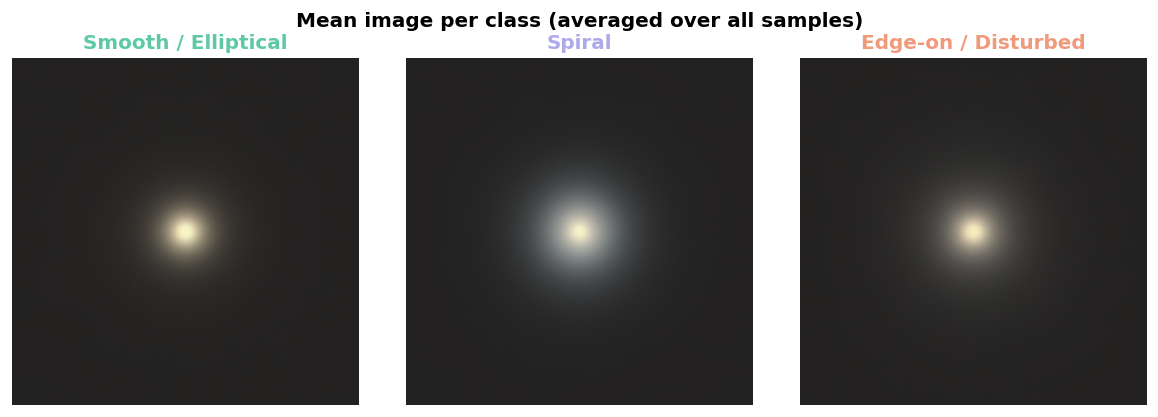

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
fig.suptitle("Mean image per class (averaged over all samples)", fontweight="bold")

for cls, (ax, name, color) in enumerate(zip(axes, class3_names, class3_colors)):
    mean_img = X[y3 == cls].mean(axis=0).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(name, color=color, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig("../results/mean_images.png", bbox_inches="tight", dpi=150)
plt.show()

## 6. Pixel statistics

In [7]:
# normalise to [0, 1] for stats
X_norm = X.astype(np.float32) / 255.0

print("Global pixel stats (across all images + channels):")
print(f"  mean : {X_norm.mean():.4f}")
print(f"  std  : {X_norm.std():.4f}")
print(f"  min  : {X_norm.min():.4f}")
print(f"  max  : {X_norm.max():.4f}")

print("\nPer-channel (R / G / B):")
for i, ch in enumerate(["R", "G", "B"]):
    print(f"  {ch}: mean={X_norm[...,i].mean():.4f}  std={X_norm[...,i].std():.4f}")

Global pixel stats (across all images + channels):
  mean : 0.1630
  std  : 0.1197
  min  : 0.0000
  max  : 1.0000

Per-channel (R / G / B):
  R: mean=0.1675  std=0.1287
  G: mean=0.1626  std=0.1180
  B: mean=0.1589  std=0.1116


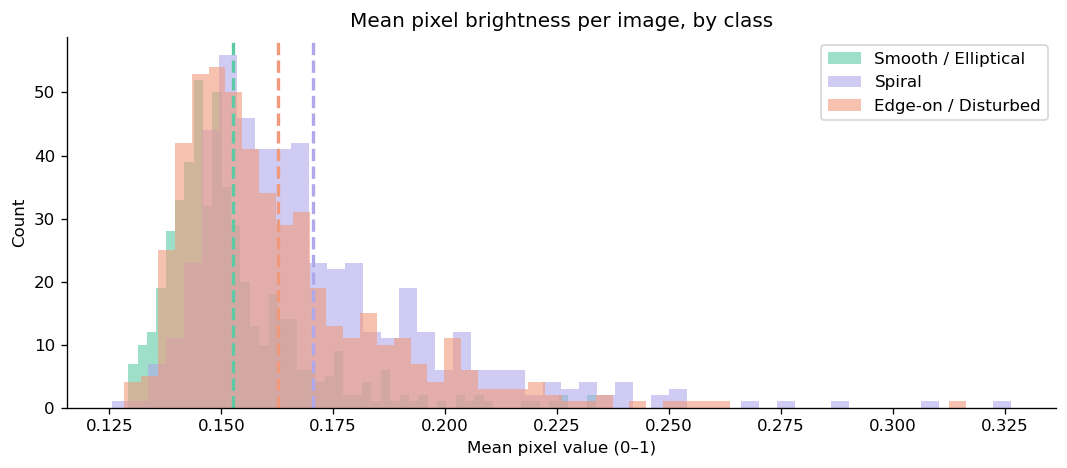


Note: edge-on/disturbed galaxies tend to be brighter on average
because they pack more light into a smaller projected area.


In [8]:
# pixel brightness distributions by class
fig, ax = plt.subplots(figsize=(9, 4))

for cls, (name, color) in enumerate(zip(class3_names, class3_colors)):
    # sample 500 images per class for speed
    idxs   = np.where(y3 == cls)[0]
    sample = np.random.choice(idxs, size=min(500, len(idxs)), replace=False)
    vals   = X_norm[sample].mean(axis=(1,2,3))   # mean brightness per image
    ax.hist(vals, bins=50, alpha=0.6, color=color, label=name, edgecolor="none")
    ax.axvline(vals.mean(), color=color, linewidth=2, linestyle="--")

ax.set_title("Mean pixel brightness per image, by class")
ax.set_xlabel("Mean pixel value (0–1)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("../results/brightness_by_class.png", bbox_inches="tight")
plt.show()

print("\nNote: edge-on/disturbed galaxies tend to be brighter on average")
print("because they pack more light into a smaller projected area.")

## 7. Radial brightness profiles
Galaxies have characteristic light profiles depending on morphology.
Smooth ellipticals follow a steep de Vaucouleurs profile.
Spirals have a shallower exponential disk.
Edge-on galaxies look elongated: the profile will be wider/flatter.


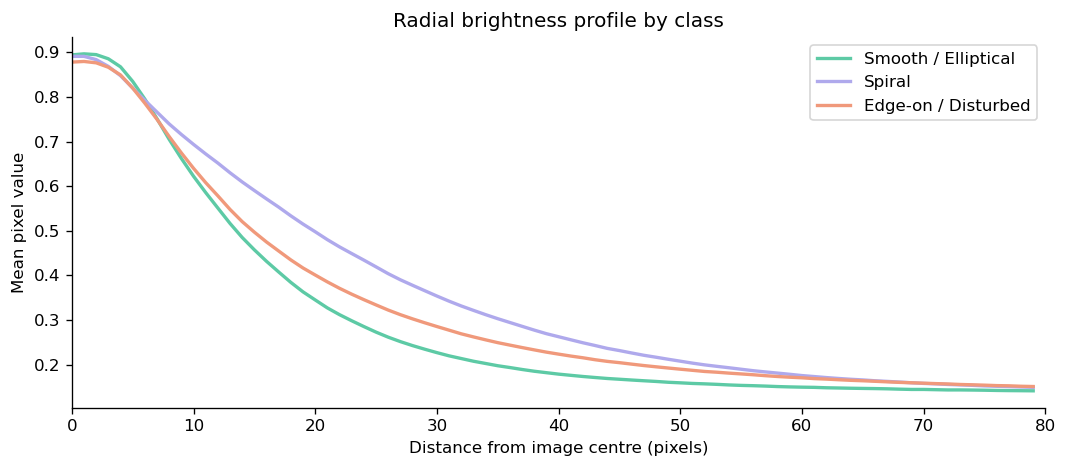

In [9]:
cx, cy = 128, 128   # centre of 256x256 image
y_idx, x_idx = np.indices((256, 256))
r = np.sqrt((x_idx - cx)**2 + (y_idx - cy)**2).astype(int)

fig, ax = plt.subplots(figsize=(9, 4))

for cls, (name, color) in enumerate(zip(class3_names, class3_colors)):
    idxs   = np.where(y3 == cls)[0]
    sample = np.random.choice(idxs, size=min(300, len(idxs)), replace=False)
    mean_img = X_norm[sample].mean(axis=(0, 3))   # avg over images + channels → (256,256)

    r_max = 80
    profile = [mean_img[r == radius].mean() if (r == radius).any() else 0
               for radius in range(r_max)]
    ax.plot(profile, color=color, linewidth=2, label=name)

ax.set_title("Radial brightness profile by class")
ax.set_xlabel("Distance from image centre (pixels)")
ax.set_ylabel("Mean pixel value")
ax.set_xlim(0, 80)
ax.legend()
plt.tight_layout()
plt.savefig("../results/radial_profiles.png", bbox_inches="tight")
plt.show()

## 8. Save processed arrays
Resize to 64×64 grayscale for the NumPy MLP, and keep 256×256 RGB for PyTorch.


In [10]:
from PIL import Image as PILImage

SAVE = True   # flip to False once you've run it once

if SAVE:
    # 64x64 grayscale for NumPy MLP
    print("Resizing to 64x64 grayscale ...")
    X_small = np.zeros((len(X), 64*64), dtype=np.float32)
    for i in range(len(X)):
        img = PILImage.fromarray(X[i]).convert("L").resize((64, 64))
        X_small[i] = np.array(img).flatten() / 255.0
        if (i+1) % 3000 == 0:
            print(f"  {i+1}/{len(X)}")

    X_tv, X_test, y_tv, y_test = train_test_split(
        X_small, y3, test_size=0.15, stratify=y3, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=0.15/0.85, stratify=y_tv, random_state=42
    )

    for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test),
                       ("y_train", y_train), ("y_val", y_val), ("y_test", y_test)]:
        np.save(f"../data/processed/{name}.npy", arr)
        print(f"  saved {name}.npy  {arr.shape}")

    print("\nClass balance in train set:", dict(zip(*np.unique(y_train, return_counts=True))))

Resizing to 64x64 grayscale ...
  3000/17736
  6000/17736
  9000/17736
  12000/17736
  15000/17736
  saved X_train.npy  (12414, 4096)
  saved X_val.npy  (2661, 4096)
  saved X_test.npy  (2661, 4096)
  saved y_train.npy  (12414,)
  saved y_val.npy  (2661,)
  saved y_test.npy  (2661,)

Class balance in train set: {np.int64(0): np.int64(3504), np.int64(1): np.int64(4550), np.int64(2): np.int64(4360)}


## 9. Summary

In [17]:
print("EDA summary")
print()
print(f"Total images : {len(X):,}")
print(f"Image size   : 256 x 256 x 3 (RGB)")
print()
for cls, name in enumerate(class3_names):
    n   = (y3 == cls).sum()
    pct = n / len(y3) * 100
    bar = "█" * int(pct / 2)
    print(f"  {cls}  {name:<25} {n:>5,}  ({pct:.1f}%)  {bar}")

print()
print("Normalisation for NumPy MLP : divide by 255  ->  [0, 1]")
print("Normalisation for ResNet-18 : ImageNet mean/std per channel")
print()
print("Class imbalance : fairly balanced - no SMOTE needed")
print("Augmentation    : random flips + rotation (galaxies are isotropic)")

EDA summary

Total images : 17,736
Image size   : 256 x 256 x 3 (RGB)

  0  Smooth / Elliptical       5,006  (28.2%)  ██████████████
  1  Spiral                    6,500  (36.6%)  ██████████████████
  2  Edge-on / Disturbed       6,230  (35.1%)  █████████████████

Normalisation for NumPy MLP : divide by 255  ->  [0, 1]
Normalisation for ResNet-18 : ImageNet mean/std per channel

Class imbalance : fairly balanced - no SMOTE needed
Augmentation    : random flips + rotation (galaxies are isotropic)
